In [1]:
from memory_system.memory_manager import MemoryManager

In [2]:
from datetime import datetime

from typing import Annotated, TypedDict, List, Literal
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.checkpoint.memory import MemorySaver

from graphiti_core.nodes import EpisodeType
from graphiti_core.search import search_config_recipes

from agent_framwork.tools import base_tools

from tools.perf_tool import perf_print

In [3]:
import sys

print("【当前解释器路径】:", sys.executable)
print("【当前版本】:", sys.version)

【当前解释器路径】: /opt/anaconda3/envs/Python11/bin/python
【当前版本】: 3.11.14 | packaged by conda-forge | (main, Oct 22 2025, 22:56:31) [Clang 19.1.7 ]


In [4]:
# # 日志
# import logging
# logging.basicConfig(level=logging.DEBUG)

In [5]:
# import os
# import shutil
# import kuzu
# from memory_system.memory_manager import MemoryManager

# # 1. 尝试关闭现有的单例（如果存在）
# try:
#     mgr = MemoryManager()
#     if mgr._initialized:
#         await mgr.close()
# except Exception:
#     pass

# # 2. 清理 Kuzu 的锁文件 (解决 "File locked" 崩溃)
# db_path = "db/graphiti.kuzu"
# lock_file = os.path.join(db_path, ".lock")

# if os.path.exists(lock_file):
#     try:
#         os.remove(lock_file)
#         print(f"🧹 强制删除了残留锁文件: {lock_file}")
#     except Exception as e:
#         print(f"⚠️ 无法删除锁文件 (可能正被占用): {e}")

In [6]:
# model_api_base = "https://dashscope.aliyuncs.com/compatible-mode/v1"
# model_api_key = "sk-7a3958e0fdf840e49a2edd83b25dd228"
# model_name = "qwen-max"

model_api_base = "https://open.bigmodel.cn/api/paas/v4"
model_api_key = "61383e606d871c028870a8f251a77f08.JH0An7yUOzhd8cIi"
model_name = "glm-4.6"

# embedding_model_name = "text-embedding-v4"
# reranker_model_name = "gte-rerank-v2"

### langchain基本组件

In [7]:
model = ChatOpenAI(
        model_name = model_name,
        openai_api_base = model_api_base,
        openai_api_key = model_api_key,
        streaming = False,
        verbose = True
    )
output_parser = StrOutputParser()

tools = [base_tools.search_fact_memories, base_tools.search_episode_memories]
llm_with_tools = model.bind_tools(tools)

In [8]:
MAX_CONTEXT_SIZE = 20

def _filter_messages(messages, k=20):
        """
        用于删减上下文长度
        """
        return messages[-k:]

### chain设置

In [9]:
# 提示词模板
system_template = """你扮演的角色名叫{name}，{description}。
向你发送信息的是系统管理员，它会不断告诉你关于周遭的情况。你需要根据情况做出相应的反应。
现在时间:
{curtime}
你刚联想到:
{mem_fact}

{mem_episode}
"""
prompt_template = ChatPromptTemplate.from_messages(
    [
        ("system", system_template),
        MessagesPlaceholder(variable_name="messages")
    ]
)

In [10]:
chain = (
    prompt_template 
    | llm_with_tools
    )

### 其他实例

In [11]:
# 记忆
memory_manager = MemoryManager()

### 图状态及节点

In [12]:
class State(TypedDict):
    name: str # agent名称
    index: int # agent id
    description: str # agent描述
    messages: Annotated[list, add_messages] # agent上下文
    group_id: str # graphiti的group_id，用于分区
    mem_fact: str # 检索到的事实记忆
    mem_episode: str # 检索到的情景记忆
    mem_to_save: str # 待存储的记忆
    logged_tool_call_ids: list[str] # 用于记忆工具调用时，去重tool_message中重试的部分

In [13]:
async def search_memory(state: State):
    """
    根据用户问题，检索事实记忆和情景记忆
    """
    query = state['messages'][-1].content
    group_id = state['group_id']
    limit = 1 # 检索的记忆数量

    mem_fact = ""
    mem_episode = ""
    
    perf_print("memory_manager初始化开始")
    await memory_manager.initialize()  # 确保初始化完成

    perf_print("rag事实记忆开始")
    memories = await memory_manager.graphiti.search(
        query, 
        # COMBINED 检索能一次性获取事实（edges）、实体（nodes）和主题（communities）。
        # RRF速度快
        # config=search_config_recipes.COMBINED_HYBRID_SEARCH_RRF, 
        num_results = limit,
        group_ids=[group_id]
    )
    for memory in memories:
        # print(memory) # 测试
        mem_fact += f"- {memory.fact}\n"
        if hasattr(memory, 'valid_at') and memory.valid_at:
            mem_fact += f'事实产生时间: {memory.valid_at}\n'
        if hasattr(memory, 'invalid_at') and memory.invalid_at:
            mem_fact += f'事实失效时间: {memory.invalid_at}\n'
        mem_fact += '---\n'
    print(f'{mem_fact}')
    perf_print("rag事实记忆完成")

    perf_print("rag情景记忆开始")
    time_key = "valid_at" # 表里的时间key
    episodes_uuid_list = []
    memories = await memory_manager.graphiti._search(
        query, 
        config=search_config_recipes.EDGE_HYBRID_SEARCH_RRF, 
        group_ids=[group_id]
    )
    for memory in memories.edges:
        if hasattr(memory, 'episodes') and memory.episodes:
            episodes_uuid_list += memory.episodes
    condition = f"WHERE n.uuid in {episodes_uuid_list}" if episodes_uuid_list else ""
    cypher = f"""
        MATCH (n: Episodic) {condition}
        RETURN n
        ORDER BY n.{time_key} ASC
        LIMIT {limit};
        """ 
    # print(cypher)
    # 检索episodes的实际内容
    try:
        response = await memory_manager.conn.execute(cypher)
        for row in response.rows_as_dict():
            memory = row['n']
            mem_episode += f"情景: \"{memory['content']}\"\n"
            # if 'valid_at' in memory:
            #     valid_at_time_str = memory[time_key].strftime('%Y-%m-%d %H:%M:%S')
            #     mem_episode += f"发生时间: {valid_at_time_str}\n"
            mem_episode += "---\n"
    except RuntimeError as e: # 一般为刚刚建立库，检索失败
        print(f"情景记忆检索失败: {e}")
    print(f'{mem_episode}')
    perf_print("rag情景记忆完成")

    # 需要存储接收到的用户信息
    perf_print("缓存记忆开始")
    now= datetime.now()
    cur_time = now.strftime("【%Y年%m月%d日 %H:%M】")
    mem_to_save = f"{cur_time}{state['name']}收到信息: {query}"
    perf_print("缓存记忆完成")
    
    print(mem_to_save) # 测试
    return {
        "mem_fact": mem_fact, 
        "mem_episode": mem_episode,
        "mem_to_save": mem_to_save
    }

In [14]:
async def chatbot(state: State):
    mem_to_save = state['mem_to_save']
    prompt = prompt_template.invoke({"messages": state['messages'],
                                     "name": state['name'],
                                     "description": state['description'],
                                     "curtime": datetime.now(),
                                     "mem_fact": state['mem_fact'],
                                     "mem_episode": state['mem_episode']})
    # print(f"【prompt】:{prompt}") # 测试
    # for message in prompt.messages:
    #     message.pretty_print()
    # response = await llm_with_tools.ainvoke(prompt)
    perf_print("模型输出开始")
    response = await llm_with_tools.ainvoke(prompt)
    print(response.content)
    perf_print("模型输出完成")
    

    # 需要存储接收到的用户信息
    if response.content.strip(): # 工具调用时，response.content为空
        perf_print("缓存记忆开始")
        now= datetime.now()
        cur_time = now.strftime("【%Y年%m月%d日 %H:%M】")
        mem_to_save += "\n" + f"{cur_time}{state['name']}心想: {response.content}"
        perf_print("缓存记忆完成")
        # print(mem_to_save)
    
    return {
        "messages": [response], 
        "mem_to_save": mem_to_save
    }

In [15]:
def cache_tool_mem(state: State):
    """
    缓存工具记忆
    """
    messages = state["messages"]
    mem_to_save = state.get("mem_to_save", "")
    logged_ids = set(state.get("logged_tool_call_ids", []))

    # 找到最后一条AI Message（即tool call的内容）
    last_ai_message = None
    for msg in reversed(messages):
        if isinstance(msg, AIMessage):
            last_ai_message = msg
            break

    if not last_ai_message or not last_ai_message.tool_calls:
        return {} # 找不到tool call就无需进行任何更新

    new_entries = []
    new_ids = []

    for tool_call in last_ai_message.tool_calls:
        tid = tool_call["id"]
        if tid not in logged_ids:
            now= datetime.now()
            cur_time = now.strftime("【%Y年%m月%d日 %H:%M】")
            new_entries.append(f"{cur_time}{state['name']} 使用了 {tool_call['name']}，输入为 {tool_call['args']}")
            new_ids.append(tid)

    if new_entries:
        mem_to_save += "\n" + "\n".join(new_entries)
        logged_ids.update(new_ids)

    return {
        "mem_to_save": mem_to_save,
        "logged_tool_call_ids": list(logged_ids)  # 注意：set 不能直接存，需转 list 或保持为 set（取决于 state schema）
    }

In [16]:
async def save_memory(state: State):
    """
    将所有缓存记忆存入graphiti
    """
    mem_to_save = state['mem_to_save']
    
    perf_print("存储记忆开始")
    print("【待存储记忆start】")
    print(mem_to_save)
    print("【待存储记忆end】")
    curtime = datetime.now()
    await MemoryManager().graphiti.add_episode(
        name=f"{state['name']}_mem_{curtime}",
        episode_body=mem_to_save,
        source=EpisodeType.text,
        source_description=f"{state['name']}_mem_{curtime}", 
        reference_time=curtime,
        group_id=state['group_id']
    )
    perf_print("存储记忆完成")

    return {"mem_to_save": ""}

### 条件

In [17]:
def route_chatbot(state: State) -> Literal["tools", "save_memory"]:
    messages = state["messages"]
    if not messages:
        raise ValueError("No messages in state")
    
    last_message = messages[-1]
    
    if isinstance(last_message, AIMessage) and last_message.tool_calls:
        return "tools"
    else:
        return "save_memory"

### 创建图

In [18]:
graph_builder = StateGraph(State)

graph_builder.add_node("search_memory", search_memory)
graph_builder.add_node("chatbot", chatbot)
tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)
graph_builder.add_node("cache_tool_mem", cache_tool_mem)
graph_builder.add_node("save_memory", save_memory)

graph_builder.add_edge(START, "search_memory")
graph_builder.add_edge("search_memory", "chatbot")
# graph_builder.add_conditional_edges(
#     "chatbot",
#     tools_condition,
# )
graph_builder.add_conditional_edges(
    "chatbot",
    route_chatbot,
    {
        "tools": "tools",
        "save_memory": "save_memory"
    }
)
graph_builder.add_edge("tools", "cache_tool_mem")
graph_builder.add_edge("cache_tool_mem", "chatbot")
graph_builder.add_edge("save_memory", END)

In [19]:
memory = MemorySaver()
compiled_graph = graph_builder.compile(checkpointer=memory)

In [20]:
import subprocess
import os
from IPython.display import Image, display
# from mermaid import Mermaid

In [21]:
def display_mermaid_cli(graph_code):
    # 1. 把代码保存为临时文件
    with open("temp.mmd", "w") as f:
        f.write(graph_code)
    
    # 2. 查找 mmdc 命令路径 (通常在 conda 的 bin 目录下)
    # 如果提示 command not found，可能需要指定绝对路径，如 /opt/anaconda3/envs/Python11/bin/mmdc
    try:
        # 调用命令行工具转成 PNG
        subprocess.run(["mmdc", "-i", "temp.mmd", "-o", "temp.png"], check=True)
        
        # 3. 显示图片
        display(Image(filename="temp.png"))
    except Exception as e:
        print(f"CLI 渲染失败: {e}")
        print("请确保已执行: npm install -g @mermaid-js/mermaid-cli")

In [22]:
# %pip install mermaid-py

Generating single mermaid chart


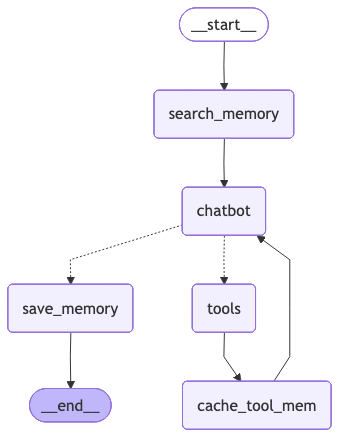

In [23]:
display_mermaid_cli(compiled_graph.get_graph().draw_mermaid())

In [24]:
# user_input="来自用户: 小红是公司的llm工程师" 
# user_input="来自用户: 小红转岗为Agent工程师了" 
user_input="来自用户: 小红的岗位是啥？" 
# user_input="来自用户: 小红到底是不是llm工程师？"
# user_input="来自用户: 进一步确认小红目前的岗位"
# user_input="请梳理一下小红岗位变动的经过"
# user_input="很好，请记住了，别下次问你又忘了"
# user_input="来自用户: 小强是谁？"
# user_input="来自小亮: 用户之前问过关于小红岗位的事情吗？"
# user_input="来自小亮: 昨天发生了哪些事情？"

# user_input="来自用户: 记住了，小红现在不是llm工程师，她是Agent工程师"
# user_input="那天发生了哪些事情？"


name = "小明"
description = "是一个帮助机器人"
group_id = "langgraph_test_1"

config = {"configurable": {"thread_id": group_id}}
state = {"name":name,
         "description": description,
         "messages": [HumanMessage(content=user_input)], 
         "group_id": group_id}

response = await compiled_graph.ainvoke(state, config)
# output = response["messages"][-1].content
# print(f"智能体: {output}")
# print(response)

性能节点:0  距上个节点: 0.0s  距离第一个节点0.0s  节点信息:memory_manager初始化开始  
✅ Graphiti_kuzu索引和约束已构建完成
性能节点:1  距上个节点: 0.15600204467773438s  距离第一个节点0.15600204467773438s  节点信息:rag事实记忆开始  
事实: "小红现在转岗成为了Agent工程师。"
事实产生时间: 2025-11-26 17:28:00+00:00
---

性能节点:2  距上个节点: 0.6592140197753906s  距离第一个节点0.815216064453125s  节点信息:rag事实记忆完成  
性能节点:3  距上个节点: 9.059906005859375e-06s  距离第一个节点0.8152251243591309s  节点信息:rag情景记忆开始  
情景: "【2025年12月01日 17:25】小明收到信息: 来自用户: 小红是llm工程师吗？
【2025年12月01日 17:25】小明心想: 

【2025年12月01日 17:25】小明 使用了 search_fact_memories，输入为 {'obj': '小红'}
【2025年12月01日 17:26】小明心想: 
根据我的记忆，我确实记录过"小红是公司的llm工程师"这个信息，但是这个事实的失效时间是2025年11月26日17:28:00，现在已经超过了那个时间。所以这个信息可能已经不再准确了。

建议您确认一下小红目前的职位情况，或者如果需要准确的信息，可以向公司内部的相关部门询问。"
---

性能节点:4  距上个节点: 0.195220947265625s  距离第一个节点1.0104460716247559s  节点信息:rag情景记忆完成  
性能节点:5  距上个节点: 1.3113021850585938e-05s  距离第一个节点1.0104591846466064s  节点信息:缓存记忆开始  
性能节点:6  距上个节点: 3.600120544433594e-05s  距离第一个节点1.0104951858520508s  节点信息:缓存记忆完成  
【2025年12月03日 17:47】小明收到信息: 来自用户: 小红的岗位是啥？
性能节点

In [25]:
# 必须释放 memory_manager.close()，断开与kuzu的read_write链接
# await memory_manager.close()

### 添加社群

In [26]:
# await memory_manager.initialize() 

In [27]:
# await memory_manager.graphiti.build_communities()

### 对话

In [28]:
# def run_conversation(user_input: str, mem0_user_id: str):
#     config = {"configurable": {"thread_id": mem0_user_id}}
#     state = {"messages": [HumanMessage(content=user_input)], "mem0_user_id": mem0_user_id}

#     response = compiled_graph.invoke(state, config)
#     output = response["messages"][-1].content
#     print(f"智能体: {output}")

In [29]:
# print("Welcome to Customer Support! How can I assist you today?")
# mem0_user_id = "customer_123"  # You can generate or retrieve this based on your user management system
# while True:
#     user_input = input("用户: ")
#     if user_input.lower() in ['quit', 'exit', 'bye']:
#         print("智能体: Thank you for contacting us. Have a great day!")
#         break
#     run_conversation(user_input, mem0_user_id)

In [30]:
# import importlib.util

# # 将 'requests' 替换为你想查询的包名
# package_name = 'graphiti_core'

# spec = importlib.util.find_spec(package_name)
# if spec is not None:
#     print(f"包 '{package_name}' 的位置: {spec.origin}")
#     print(f"包所在的目录: {spec.submodule_search_locations}")
# else:
#     print(f"未找到包 '{package_name}'")

### 显示图谱

In [31]:
# import kuzu
# from yfiles_jupyter_graphs_for_kuzu import KuzuGraphWidget
# from IPython.display import display

In [32]:
# db_path = "db/graphiti.kuzu"
# read_only_db = kuzu.Database(db_path, read_only=True)

In [33]:
# sync_conn_for_widget = kuzu.Connection(read_only_db)

In [34]:
# g = KuzuGraphWidget(sync_conn_for_widget)

In [35]:
# cypher = """
# MATCH (a)-[b]->(c) 
# RETURN * LIMIT 50
# """
# g.show_cypher(cypher)

In [36]:
# import kuzu
# from yfiles_jupyter_graphs_for_kuzu import KuzuGraphWidget
# from IPython.display import display
# from memory_system.memory_manager import MemoryManager

In [37]:
# # 1. 获取已经初始化的 MemoryManager 实例
# memory_manager = MemoryManager()
# await memory_manager.initialize()

In [38]:
# # 2. 从 AsyncConnection 的连接池中安全地“借”一个同步连接
# #    这是官方推荐的方式，可以避免所有冲突
# sync_conn_for_widget = memory_manager.conn.acquire_connection()

In [39]:
# try:
#     # 3. 创建可视化组件
#     g = KuzuGraphWidget(sync_conn_for_widget)

#     # 4. 执行查询
#     cypher = """
#     MATCH (a)-[b]->(c) 
#     RETURN * LIMIT 50
#     """
#     g.show_cypher(cypher)

# finally:
#     # 5. 非常重要：用完后必须“归还”连接
#     #    这样 AsyncConnection 才能正确地管理它的连接池
#     memory_manager.conn.release_connection(sync_conn_for_widget)

In [40]:
# import kuzu
# from yfiles_jupyter_graphs_for_kuzu import KuzuGraphWidget
# from IPython.display import display
# import gc # 引入垃圾回收
# from memory_system.memory_manager import MemoryManager

In [41]:
# # 1. 临时获取 Database 对象引用
# # 注意：MemoryManager 必须已经初始化
# if not MemoryManager()._initialized:
#     await MemoryManager().initialize()

In [42]:
# real_db = MemoryManager().kuzu_driver.db

In [43]:
# # 定义变量名，防止 finally 中访问报错
# temp_sync_conn = None

In [44]:
# try:
#     print("🎨 开始生成图谱可视化...")
    
#     # 2. 【关键】创建一个临时的、短命的同步连接 (Reader)
#     # 它是 Reader，它存在期间，Writer 可能会受限
#     temp_sync_conn = kuzu.Connection(real_db)
    
#     # 3. 初始化组件并显示
#     g = KuzuGraphWidget(temp_sync_conn)
#     display(g)
    
#     # 4. 执行查询
#     # 【必须加 LIMIT】KuzuGraphWidget 渲染大量节点会导致前端崩溃
#     cypher = """
#     MATCH (a)-[b]->(c) 
#     RETURN * LIMIT 50
#     """
#     g.show_cypher(cypher)
#     print("✅ 图谱已发送至前端")

# except Exception as e:
#     print(f"❌ 可视化出错: {e}")

# finally:
#     # 5. 【核心修正】强制销毁连接
#     # 画图指令发送给前端后，后端的 Python 连接必须断开
#     if temp_sync_conn:
#         try:
#             if hasattr(temp_sync_conn, 'close'):
#                 temp_sync_conn.close()
#         except:
#             pass
        
#         # 彻底删除 Python 引用
#         del temp_sync_conn
    
#     # 6. 强制垃圾回收
#     # 这一步会触发 C++ 底层的析构函数，立即释放文件锁
#     gc.collect()
#     print("🧹 可视化连接已强制销毁，数据库锁已释放")